In [ ]:
!pip install datasets sentencepiece sacrebleu rouge-score torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.4 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24986 sha256=1a12ef9e99e9a64de28a01c98b9393d8d6d4171bed9ca42081dca884a1a2b725
  Stored in directory: /root/.cache/pip/wheels/44/af/da/5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score


In [ ]:
from datasets import load_dataset
import csv
import matplotlib.pyplot as plt

In [ ]:
ds = load_dataset("uqa/UQA")
print(ds)

README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file:   0%|          |  0.00B / 30.2MB            

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-cf8a6960d(…): reconstructing file:   0%|          |  0.00B / 2.92MB            

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/124745 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16824 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})


In [ ]:
ex = ds["train"][0]
print(ex.keys())

dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])


In [ ]:
print(ex["question"])
print(ex["answer"])

بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
1990 کی دہائی کے آخر میں


In [ ]:
n_total = len(ds["train"])
n_ans = n_total - sum(ds["train"]["is_impossible"])
print (f"train rows: {n_total}, answerable: {n_ans}")

train rows: 124745, answerable: 83018


In [ ]:
ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"
SOS_TOKEN, EOS_TOKEN = "<s>", "</s>"
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"
SENT_DELIMS = "\u06D4\u061F!"

In [ ]:
def split_sentences(text):
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start : i + 1]
            start = i + 1
    if start < len(text):
        yield start, len(text), text[start:]

In [ ]:
def make_pair(example, max_src=60, max_tgt=25):
    if example["is_impossible"]:
        return None
    a_start = example["answer_start"]
    a_text = example["answer"]
    a_end = a_start + len(a_text)
    context = example["context"]
    for s, e, sent in split_sentences(context):
        if s <= a_start < e:
            rel = a_start - s
            if sent[rel : rel + len(a_text)] != a_text:
                return None
            src = (sent[:rel] + " " + ANS_OPEN + " " + a_text + " " + ANS_CLOSE + " " + sent[rel + len(a_text) :]).strip()
            src = " ".join(src.split())
            tgt = " ".join(example["question"].split())
            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None
            return src, tgt
    return None

In [ ]:
def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]
    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(f, delimiter="\t", quoting=csv.QUOTE_NONE, escapechar="\\")
        w.writerows(pairs)
    print(f"{out_path}: {len(pairs)} pairs")
    return pairs

In [ ]:
train_pairs = build_split(ds["train"], "train.tsv")
valid_pairs = build_split(ds["validation"], "valid.tsv")

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


In [ ]:
print(f"train: \n\ttotal: {len(ds['train'])} \n\tanswerable: {len(ds['train']) - sum(ds['train']['is_impossible'])} \n\tselected: {len(train_pairs)}\n")
print(f"validation: \n\ttotal: {len(ds['validation'])} \n\tanswerable: {len(ds['validation']) - sum(ds['validation']['is_impossible'])} \n\tselected: {len(valid_pairs)}\n")

train: 
	total: 124745 
	answerable: 83018 
	selected: 75067

validation: 
	total: 16824 
	answerable: 11169 
	selected: 10018



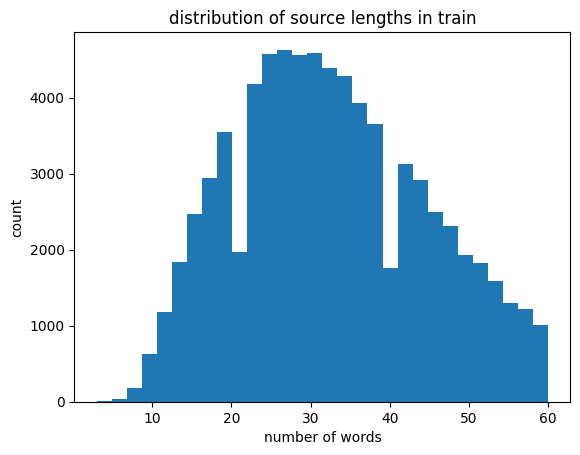

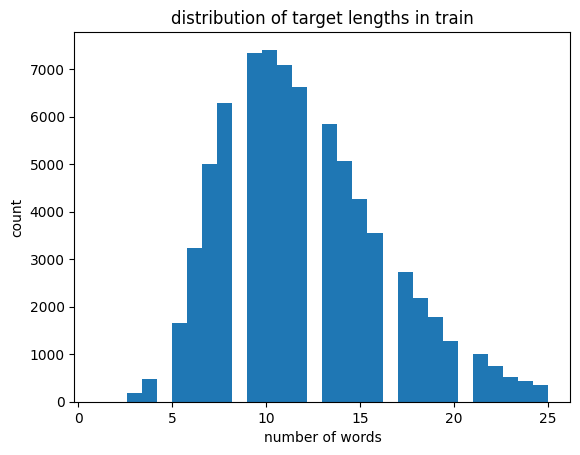

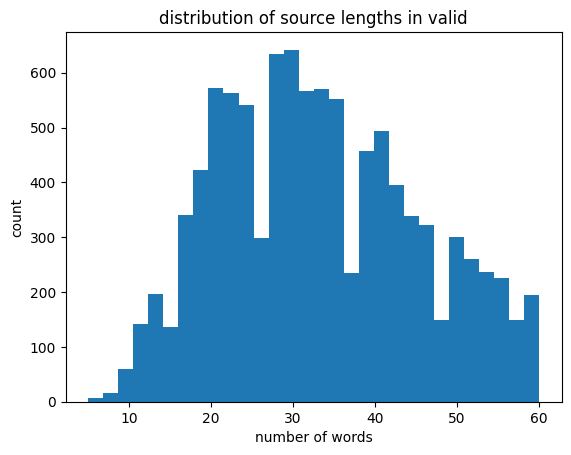

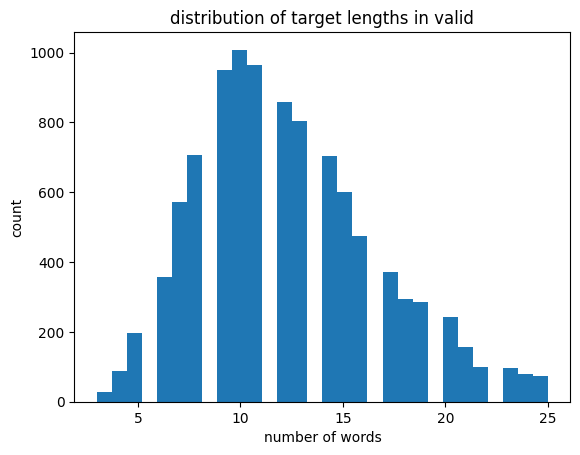

In [ ]:
plt.figure()
plt.hist([len(src.split()) for src, _ in train_pairs], bins=30, label="train source")
plt.title("distribution of source lengths in train")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist([len(tgt.split()) for _, tgt in train_pairs], bins=30, label="train target")
plt.title("distribution of target lengths in train")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist([len(src.split()) for src, _ in valid_pairs], bins=30, label="valid source")
plt.title("distribution of source lengths in valid")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist([len(tgt.split()) for _, tgt in valid_pairs], bins=30, label="valid target")
plt.title("distribution of target lengths in valid")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

In [ ]:
import sentencepiece as spm

In [ ]:
with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n" + tgt + "\n")

In [ ]:
spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="ur_sp",
    vocab_size=8000,
    model_type="unigram",
    character_coverage=1.0,
    user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

True

In [ ]:
sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
src, tgt = train_pairs[0]
print(sp.encode(src, out_type=str))
print(sp.encode(tgt))
print(sp.decode(sp.encode(tgt)) == tgt)

['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']
[2757, 18, 83, 2810, 100, 151, 99, 9, 11]
True


In [ ]:
for src, _ in train_pairs[:5]:
    print(f"original: {src}\ntokenized: {sp.encode(src, out_type=str)}\n\n")

original: ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
tokenized: ['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']


original: ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں آر اینڈ بی گرل گروپ ڈسٹنی چائلڈ کی لیڈ گلوکارہ کی حیثیت سے شہرت حاصل کی۔
tokenized: ['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁اور', '▁پرورش', '▁پائی', '▁،

In [ ]:
sp.encode(train_pairs[0][1])

[2757, 18, 83, 2810, 100, 151, 99, 9, 11]

In [ ]:
sp.encode(train_pairs[0][1], add_bos=True, add_eos=True)

[2, 2757, 18, 83, 2810, 100, 151, 99, 9, 11, 3]

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=True,
        )
        self.hidden = nn.Linear(hidden_size * 2, hidden_size)
        self.cell = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, x, lengths):
        x_len = x.size(0)
        x = pack_padded_sequence(x, lengths.cpu(), enforce_sorted=False)
        packed_outputs, (hidden, cell) = self.lstm(x)
        outputs, _ = pad_packed_sequence(packed_outputs, total_length=x_len)
        return outputs, self.hidden(torch.cat((hidden[::2], hidden[1::2]), dim=2)), self.cell(torch.cat((cell[::2], cell[1::2]), dim=2))

In [ ]:
class LuongAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attentionW = nn.Linear(2 * hidden_size, hidden_size)

    def forward(self, enc_hiddens, dec_hidden, mask):
        scores = self.attentionW(enc_hiddens).transpose(0, 1) @ dec_hidden.unsqueeze(2)
        scores = scores.masked_fill(mask.unsqueeze(2) == 0, float("-inf"))
        attn_weights = F.softmax(scores, dim=1)
        context = attn_weights.transpose(1, 2) @ enc_hiddens.transpose(0, 1)
        return context.squeeze(1), attn_weights.squeeze(2)

In [ ]:
class Decoder(nn.Module):
    def __init__(self, attention, vocab_size, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
        )
        self.attention = attention
        self.h_att_layer = nn.Linear(3 * hidden_size, hidden_size)
        self.out_layer = nn.Linear(hidden_size, vocab_size)

    def forward(self, y_prev, h_prev, c_prev, encoder_hiddens, mask):
        x = y_prev.unsqueeze(0)
        output, (hidden, cell) = self.lstm(x, (h_prev, c_prev))
        context, attn_weights = self.attention(encoder_hiddens, output.squeeze(0), mask)
        h_att = F.tanh(self.h_att_layer(torch.cat((context, output.squeeze(0)), dim=1)))
        logits = self.out_layer(h_att)
        return logits, hidden, cell, attn_weights

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, device, pad_idx, sos_idx, eos_idx, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.attention = LuongAttention(hidden_dim)
        self.encoder = Encoder(embedding_dim, hidden_dim, num_layers, dropout)
        self.decoder = Decoder(self.attention, vocab_size, embedding_dim, hidden_dim, num_layers, dropout)
        self.device = device
        self.pad_idx = pad_idx
        self.sos_idx = sos_idx
        self.eos_idx = eos_idx

    def forward(self, x, lengths, y, teacher_forcing_ratio=0.5):
        embedded_x = self.embedding(x)
        encoder_hiddens, hidden, cell = self.encoder(embedded_x, lengths)
        outputs = torch.zeros((y.size(0) - 1, y.size(1), self.decoder.out_layer.out_features), device=self.device)
        mask = (x != self.pad_idx).transpose(0, 1)
        y_prev_token = y[0]
        for t in range(1, y.size(0)):
            embedded_y_prev = self.embedding(y_prev_token)
            logits, hidden, cell, _ = self.decoder(embedded_y_prev, hidden, cell, encoder_hiddens, mask)
            outputs[t - 1] = logits
            y_prev_token = y[t] if torch.rand(1) < teacher_forcing_ratio else logits.argmax(1)
        return outputs

    @torch.no_grad()
    def decode(self, x, lengths, max_len, beam_size=1):
        self.eval()
        embedded_x = self.embedding(x)
        enc_hiddens, enc_hidden, enc_cell = self.encoder(embedded_x, lengths)
        mask = (x != self.pad_idx).transpose(0, 1)
        results = []
        attentions = []
        def length_norm_score(item, alpha=0.7):
            score, tokens = item[0], item[1]
            lp = ((5 + len(tokens)) / 6) ** alpha
            return score / lp
        for b in range(x.size(1)):
            enc_hiddens_b = enc_hiddens[:, b : b + 1, :]
            enc_hidden_b = enc_hidden[:, b : b + 1, :].contiguous()
            enc_cell_b = enc_cell[:, b : b + 1, :].contiguous()
            mask_b = mask[b : b + 1, :]
            beams = [(
                0.0,
                [self.sos_idx],
                enc_hidden_b,
                enc_cell_b,
                False,
                []
            )]
            for _ in range(max_len):
                if all(beam[-2] for beam in beams):
                    break
                new_beams = []
                for score, tokens, h_prev, c_prev, finished, attn_hist in beams:
                    if finished:
                        new_beams.append((score, tokens, h_prev, c_prev, finished, attn_hist))
                        continue
                    y_prev_token = torch.tensor([tokens[-1]], device=self.device)
                    embedded_y_prev = self.embedding(y_prev_token)
                    logits, h, c, attn_weights = self.decoder(embedded_y_prev, h_prev, c_prev, enc_hiddens_b, mask_b)
                    attn_vec = attn_weights.squeeze(0).detach().cpu()
                    logp = F.log_softmax(logits, dim=1).squeeze(0)
                    topk_logp, topk_idxs = logp.topk(beam_size)
                    for logp, idx in zip(topk_logp.tolist(), topk_idxs.tolist()):
                        new_token = tokens + [idx]
                        new_score = score + logp
                        new_finished = finished or (idx == self.eos_idx)
                        new_attn_hist = attn_hist + [attn_vec]
                        new_beams.append((new_score, new_token, h, c, new_finished, new_attn_hist))
                beams = sorted(new_beams, key=length_norm_score, reverse=True)[:beam_size]
            best_score, best_tokens, _, _, best_finished, best_attn_hist = max(beams, key=length_norm_score)
            if best_finished:
                final_tokens = best_tokens[1:-1]
                final_attn = best_attn_hist[:-1]
            else:
                final_tokens = best_tokens[1:]
                final_attn = best_attn_hist
            attn_matrix = torch.stack(final_attn, dim=0) if final_attn else torch.empty(0, enc_hiddens_b.size(0))
            results.append(final_tokens)
            attentions.append(attn_matrix)
        return results, attentions

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
class UQADataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

In [ ]:
def collate_fn(batch, pad_idx):
    src_batch, tgt_batch = zip(*batch)
    src_batch = [torch.tensor(src) for src in src_batch]
    tgt_batch = [torch.tensor(tgt) for tgt in tgt_batch]
    src_batch = pad_sequence(src_batch, padding_value=pad_idx)
    tgt_batch = pad_sequence(tgt_batch, padding_value=pad_idx)
    return src_batch, tgt_batch

In [ ]:
BATCH_SIZE = 64

In [ ]:
train_dataset = UQADataset([(sp.encode(src), sp.encode(tgt, add_bos=True, add_eos=True)) for src, tgt in train_pairs])
valid_dataset = UQADataset([(sp.encode(src), sp.encode(tgt, add_bos=True, add_eos=True)) for src, tgt in valid_pairs])

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda x: collate_fn(x, PAD_IDX)
)
valid_dataloader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: collate_fn(x, PAD_IDX)
)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VOCAB_SIZE = sp.get_piece_size()
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.3
TF_START = 0.9
TF_END = 0.3
LEARNING_RATE = 1e-3
SCHEDULER_FACTOR = 0.5
SCHEDULE_PATIENCE = 1
SCHEDULE_COOLDOWN = 0
MIN_LR = 1e-6
WEIGHT_DECAY = 1e-5
CLIP = 5.0
NUM_EPOCHS = 15

def tf_ratio(epoch, total, start, end):
    return start + (end - start) * (epoch / total)

TF_RATIO = tf_ratio(0, NUM_EPOCHS, TF_START, TF_END)

model = Seq2Seq(
    device=device,
    pad_idx=PAD_IDX,
    sos_idx=BOS_IDX,
    eos_idx=EOS_IDX,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULE_PATIENCE,
    cooldown=SCHEDULE_COOLDOWN,
    min_lr=MIN_LR,
)

In [ ]:
num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_parameters}")

Number of trainable parameters: 21645120


In [ ]:
from tqdm import tqdm

def train_step(dataloader, model, optimizer, criterion, device, pad_idx, tf_ratio, clip):
    model.train()
    total_loss = 0
    tqdm_bar = tqdm(dataloader, desc="Training", leave=False)
    for idx, (src, tgt) in enumerate(tqdm_bar):
        src, tgt = src.to(device), tgt.to(device)
        lengths = (src != pad_idx).sum(dim=0)
        optimizer.zero_grad()
        output = model(src, lengths, tgt, tf_ratio)
        loss = criterion(output.reshape(-1, output.size(-1)), tgt[1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
        avg_loss = total_loss / (idx + 1)
        tqdm_bar.set_postfix({"avg_loss": f"{avg_loss:.4f}", "current_loss": f"{loss.item():.4f}"})
    return total_loss / len(dataloader)

def evaluation_step(dataloader, model, criterion, device, pad_idx):
    model.eval()
    total_loss = 0
    tqdm_bar = tqdm(dataloader, desc="Evaluating", leave=False)
    with torch.no_grad():
        for idx, (src, tgt) in enumerate(tqdm_bar):
            src, tgt = src.to(device), tgt.to(device)
            lengths = (src != pad_idx).sum(dim=0)
            output = model(src, lengths, tgt, 0.0)
            loss = criterion(output.reshape(-1, output.size(-1)), tgt[1:].reshape(-1))
            total_loss += loss.item()
            avg_loss = total_loss / (idx + 1)
            tqdm_bar.set_postfix({"avg_loss": f"{avg_loss:.4f}", "current_loss": f"{loss.item():.4f}"})
    return total_loss / len(dataloader)

In [ ]:
best_valid_loss = float("inf")
epoch_train_losses, epoch_valid_losses = [], []
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    TF_RATIO = tf_ratio(epoch, NUM_EPOCHS, TF_START, TF_END)
    train_loss = train_step(train_dataloader, model, optimizer, criterion, device, PAD_IDX, TF_RATIO, CLIP)
    valid_loss = evaluation_step(valid_dataloader, model, criterion, device, PAD_IDX)
    scheduler.step(valid_loss)
    epoch_train_losses.append(train_loss)
    epoch_valid_losses.append(valid_loss)
    print(f"Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")
    torch.save(model.state_dict(), f"epoch_{epoch}.pt")
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best_model.pt")
        print(f"Best model saved with loss: {best_valid_loss:.4f}")

Epoch 1/15


Train Loss: 5.2050 | Valid Loss: 7.1556
Best model saved with loss: 7.1556
Epoch 2/15


Train Loss: 4.4141 | Valid Loss: 6.9608
Best model saved with loss: 6.9608
Epoch 3/15


Train Loss: 4.0990 | Valid Loss: 6.8835
Best model saved with loss: 6.8835
Epoch 4/15


Train Loss: 3.7475 | Valid Loss: 6.7455
Best model saved with loss: 6.7455
Epoch 5/15


...

Train Loss: 3.3450 | Valid Loss: 5.9215
Best model saved with loss: 5.9215
Epoch 12/15


Train Loss: 3.3774 | Valid Loss: 5.9454
Epoch 13/15


Train Loss: 3.4167 | Valid Loss: 5.9002
Best model saved with loss: 5.9002
Epoch 14/15


Train Loss: 3.4710 | Valid Loss: 5.7973
Best model saved with loss: 5.7973
Epoch 15/15


Train Loss: 3.5044 | Valid Loss: 5.7141
Best model saved with loss: 5.7141


In [ ]:
evaluation_step(valid_dataloader, model, criterion, device, PAD_IDX), evaluation_step(train_dataloader, model, criterion, device, PAD_IDX)

(5.714124794978245, 4.098184376624742)

In [ ]:
print(f"Epoch Train Losses: {epoch_train_losses}")
print(f"Epoch Valid Losses: {epoch_valid_losses}")

Epoch Train Losses: [5.2050014595038245, 4.41410479724458, 4.0989928099200545, 3.7475206392602036, 3.4768270885243133, 3.3413102769079313, 3.2926513217802444, 3.2842013518828566, 3.315977047979578, 3.3137315270845846, 3.34500788626057, 3.377360256736541, 3.416690582509541, 3.471040584038997, 3.504401237458524]
Epoch Valid Losses: [7.155585389228383, 6.960827308095944, 6.883485122850746, 6.745458885362953, 6.547112340380432, 6.508986108621974, 6.51954347464689, 6.328960345808867, 6.266964939749165, 6.145055792134279, 5.921535813884371, 5.945395536483473, 5.900236135835101, 5.797265450665905, 5.714124794978245]


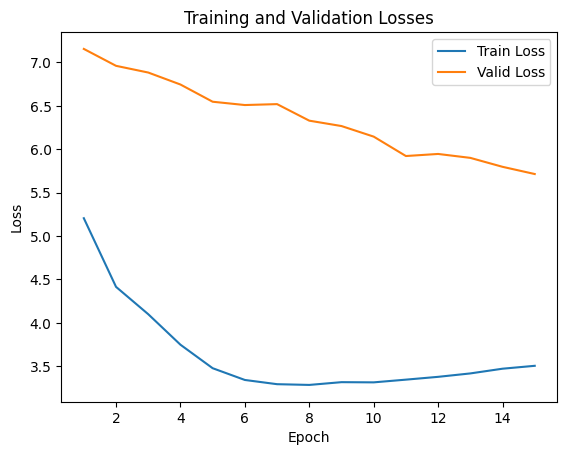

In [ ]:
plt.figure()
plt.plot(range(1, NUM_EPOCHS + 1), epoch_train_losses, label="Train Loss")
plt.plot(range(1, NUM_EPOCHS + 1), epoch_valid_losses, label="Valid Loss")
plt.title("Training and Validation Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import sacrebleu
from rouge_score import rouge_scorer

In [ ]:
class WhitespaceTokenizer:
    def tokenize(self, text):
        return text.split()

def score(hyps , refs) :
    blue = sacrebleu.corpus_bleu(hyps, [refs]).score
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False, tokenizer=WhitespaceTokenizer())
    rl = sum(scorer.score(r, h)["rougeL"].fmeasure for h, r, in zip(hyps, refs)) / len(refs)
    unk_rate = sum(h.count("\u2047") for h in hyps) / max(1, sum(len(h.split()) for h in hyps))
    return blue, rl, unk_rate

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

Seq2Seq(
  (embedding): Embedding(8000, 256, padding_idx=0)
  (attention): LuongAttention(
    (attentionW): Linear(in_features=1024, out_features=512, bias=True)
  )
  (encoder): Encoder(
    (lstm): LSTM(256, 512, num_layers=2, dropout=0.3, bidirectional=True)
    (hidden): Linear(in_features=1024, out_features=512, bias=True)
    (cell): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(256, 512, num_layers=2, dropout=0.3)
    (attention): LuongAttention(
      (attentionW): Linear(in_features=1024, out_features=512, bias=True)
    )
    (h_att_layer): Linear(in_features=1536, out_features=512, bias=True)
    (out_layer): Linear(in_features=512, out_features=8000, bias=True)
  )
)

In [ ]:
hyps, refs = [], []
with torch.no_grad():
    for src, tgt in valid_dataloader:
        src = src.to(device)
        lengths = (src != PAD_IDX).sum(dim=0)
        decoded_tokens, _ = model.decode(src, lengths, max_len=25, beam_size=5)
        for i in range(len(decoded_tokens)):
            hyp = sp.decode(decoded_tokens[i])
            ref = sp.decode([i for i in tgt[:, i].tolist() if i not in [PAD_IDX, BOS_IDX, EOS_IDX]])
            hyps.append(hyp)
            refs.append(ref)

(array([5.450e+02, 3.841e+03, 3.644e+03, 1.529e+03, 4.050e+02, 4.700e+01,
        5.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([  9.,  24.,  39.,  54.,  69.,  84.,  99., 114., 129., 144., 159.]),
 <BarContainer object of 10 artists>)

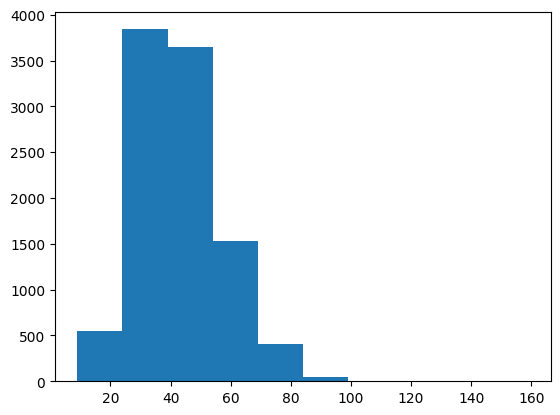

In [ ]:
plt.hist([len(h.strip()) for h in hyps])

In [ ]:
bleu, rl, unk_rate = score(hyps, refs)
print(f"BLEU: {bleu:.2f}")
print(f"ROUGE-L: {rl:.2f}")
print(f"UNK Rate: {unk_rate:.2f}")

BLEU: 7.34
ROUGE-L: 0.28
UNK Rate: 0.00


In [ ]:
refs[:15], hyps[:15]

(['نارمنڈی کس ملک میں واقع ہے؟',
  'نارمنز نارمنڈی میں کب تھے؟',
  'نارمنز نارمنڈی میں کب تھے؟',
  'نورس کس ملک سے پیدا ہوئے تھے؟',
  'نورس لیڈر کون تھا؟',
  'کس صدی میں نارمنز نے پہلی بار اپنی علیحدہ شناخت حاصل کی؟',
  'کس صدی میں نارمنز نے پہلی بار اپنی علیحدہ شناخت حاصل کی؟',
  'کس صدی میں نارمنز نے پہلی بار اپنی علیحدہ شناخت حاصل کی؟',
  'کس صدی میں نارمنز نے پہلی بار اپنی علیحدہ شناخت حاصل کی؟',
  'ہیسٹنگس کی لڑائی میں ڈیوک کون تھا؟',
  'جو نورمنڈی کے ڈچی پر حکمرانی کی',
  'نارمنز کا مذہب کیا تھا؟',
  'نارمنز کا مذہب کیا تھا؟',
  'ڈچی آف نارمنڈی کی بنیاد کب رکھی گئی تھی؟',
  'رولو نے سینٹ کلیئر سور ایپٹ کے معاہدے پر کس کے ساتھ دستخط کیے؟'],
 ['نارمن کس ملک کا علاقہ نام دیا گیا تھا؟',
  'نارمنز نے فرانس کے ایک علاقہ کب کیا؟',
  'نارمن نے فرانس کے ایک علاقے کو اپنا نام کب کیا کیا؟',
  'نارمن نے کن ممالک کے ساتھ کے ساتھ ساتھ کے ساتھ؟',
  'کس سا رہنما بادشاہ کے کے کے ساتھ وفاداری کی قسم کھانے پر اتفاق کیا؟',
  'نارمن کی ثقافتی اور نسلی شناخت کس دور میں ہوئی؟',
  'نارمن کی ثقافتی اور ن